<a id="table-of-contents"></a>

![Status: Complete](https://img.shields.io/badge/status-complete-brightgreen)
![Python](https://img.shields.io/badge/python-3.10-blue)
![Coverage](https://img.shields.io/badge/coverage-80%25-orange)
![License](https://img.shields.io/badge/license-MIT-green)

# 📖 Hypothesis Testing

[🗂️ Data Setup](#data-setup)     
- [⚙️ Define Test Configuration](#define-test-config)
- [🔍 Generate Data](#generate-data)      

[🛠️ Test Setup](#test-setup)    
- [🧪 Validate Configuration Dictionary](#validate-config)

[📈 EDA](#eda)  
- [🔍 Check Distribution From Data (Shapiro-Wilk)](#check-distribution)      
- [🔍 Check Distribution (Kolmogorov–Smirnov)](#check-distribution-ks)      
- [📊 Visual Normality Check (Q-Q Plot)](#check-distribution-qq)      
- [📏 Check Variance Equality (Levene’s Test)](#check-variance)    
- [📏 Alternative Variance Tests (FYI)](#check-variance-alt)    
- [📊 Infer Parametric Flag](#infer-parametric-flag)    

[🧪 Hypothesis Testing](#hypothesis-testing)    
- [🧭 Determine Test To Run](#determine-test)    
- [🧠 Print Hypothesis Statement](#print-hypothesis)    
- [🧪 Run Hypothesis Test](#run-test)

___

<a id="data-setup"></a>
# 🗂️ Data Setup

In [1]:
# Display Settings
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
from IPython.display import display, HTML
import warnings
import json
%load_ext autoreload
%autoreload 2

# UDF
my_seed = 1995
from ht_utils import *

<hr style="border: none; height: 1px; background-color: #ddd;" />

<a id="define-test-config"></a>
#### ⚙️ Define Test Configuration

In [2]:
config = {
    'outcome_type': 'continuous',        # continuous, binary, categorical, count
    'group_relationship': 'independent', # independent or paired
    'group_count': 'two-sample',         # one-sample, two-sample, multi-sample
    'distribution': None,                # normal or non-normal → to be inferred
    'variance_equal': None,              # equal or unequal → to be inferred
    'tail_type': 'two-tailed',           # or 'one-tailed'
    'parametric': None,                  # True or False → to be inferred
    'alpha': 0.05,                       # significance level
    'sample_size': 100,                  # per group
    'effect_size': 0.5,                  # for generating synthetic difference
}

In [3]:
pretty_json(config)
print_config_summary(config)

📋 Hypothesis Test Configuration Summary

🔸 Outcome Type         : continuous
🔸 Group Relationship   : independent
🔸 Group Count          : two-sample
🔸 Distribution         : None
🔸 Variance Equal       : None
🔸 Tail Type            : two-tailed
🔸 Parametric           : None
🔸 Alpha                : 0.05
🔸 Sample Size          : 100
🔸 Effect Size          : 0.5

🧠 Inference Summary:
→ Comparing two independent groups (A vs B).


<a id="generate-data"></a>
#### 🧪 Generate Data from Config


In [4]:
df = generate_data_from_config(config)
df

,group,value
0,A,3.759367
1,A,3.529421
2,A,7.101191
3,A,3.535178
4,A,5.817922
...,...,...
195,B,5.816507
196,B,5.218070
197,B,5.151804
198,B,5.072379


[Back to the top](#table-of-contents)

___


<a id="test-setup"></a>

# 🛠️ Test Setup

<details><summary><strong>📖 Test Settings Explanation (Click to Expand)</strong></summary>

##### 📊 **Test Type (test_type)**
This setting defines the type of test you want to perform.

- **one_sample**: Comparing the sample mean against a known value (e.g., a population mean).
- **two_sample**: Comparing the means of two independent groups (e.g., A vs B).
- **paired**: Comparing means from the same group at two different times (before vs after).
- **proportions**: Comparing proportions (e.g., the conversion rates of two groups).

**Example**: You might want to test if the mean age of two groups of people (Group A and Group B) differs, or if the proportion of people who converted in each group is different.

##### 📏 **Tail Type (tail_type)**
This setting determines whether you are performing a one-tailed or two-tailed test.

- **one_tailed**: You are testing if the value is greater than or less than the reference value (directional).
- **two_tailed**: You are testing if the value is different from the reference value, either higher or lower (non-directional).

**Example**:  
- **One-tailed**: Testing if new treatment increases sales (you only care if it's greater).  
- **Two-tailed**: Testing if there is any difference in sales between two treatments (it could be either an increase or decrease).

##### 🧮 **Parametric (parametric)**
This setting indicates whether the test is **parametric** or **non-parametric**.

- **True (Parametric)**: This means we assume that the data follows a certain distribution, often a **normal distribution**. The most common parametric tests are **t-tests** and **z-tests**. Parametric tests are generally more powerful if the assumptions are met.
- **False (Non-Parametric)**: Non-parametric tests don’t assume any specific distribution. These are used when the data doesn’t follow a normal distribution or when the sample size is small. Examples include **Mann-Whitney U** (alternative to the t-test) and **Wilcoxon Signed-Rank** (alternative to paired t-test).

**Why does this matter?**  
Parametric tests tend to be more powerful because they make assumptions about the distribution of the data (e.g., normality). Non-parametric tests are more flexible and can be used when these assumptions are not met, but they may be less powerful.

##### 📊 **Equal Variance (equal_variance)**
This setting is used specifically for **two-sample t-tests**.

- **True**: Assumes that the two groups have **equal variances** (i.e., the spread of data is the same in both groups). This is used for the **pooled t-test**.
- **False**: Assumes the two groups have **different variances**. This is used for the **Welch t-test**, which is more robust when the assumption of equal variances is violated.

**Why is this important?**  
If the variances are not equal, using a pooled t-test (which assumes equal variance) can lead to incorrect conclusions. The Welch t-test is safer when in doubt about the equality of variances.

##### 🔑 **Significance Level (alpha)**
The **alpha** level is your **threshold for statistical significance**.

- Commonly set at **0.05**, this means that you are willing to accept a 5% chance of wrongly rejecting the null hypothesis (i.e., a 5% chance of a Type I error).
- If the **p-value** (calculated from your test) is less than **alpha**, you reject the null hypothesis. If it's greater than alpha, you fail to reject the null hypothesis.

**Example**:  
- **alpha = 0.05** means there’s a 5% risk of concluding that a treatment has an effect when it actually doesn’t.

##### 🎯 **Putting It All Together**

For instance, let's say you're testing if a new feature (Group A) increases user engagement compared to the existing feature (Group B). Here’s how each configuration works together:

- **test_type** = `'two_sample'`: You're comparing two independent groups (A vs B).
- **tail_type** = `'two_tailed'`: You’re testing if there’s any difference (increase or decrease) in engagement.
- **parametric** = `True`: You assume the data is normally distributed, so a t-test will be appropriate.
- **equal_variance** = `True`: You assume the two groups have equal variance, so you’ll use a pooled t-test.
- **alpha** = `0.05`: You’re using a 5% significance level for your hypothesis test.

</details>


<hr style="border: none; height: 1px; background-color: #ddd;" />

<a id="validate-config"></a>
#### 🧪 Validate Configuration Dictionary

In [5]:
pretty_json(config)
print_config_summary(config)

📋 Hypothesis Test Configuration Summary

🔸 Outcome Type         : continuous
🔸 Group Relationship   : independent
🔸 Group Count          : two-sample
🔸 Distribution         : None
🔸 Variance Equal       : None
🔸 Tail Type            : two-tailed
🔸 Parametric           : None
🔸 Alpha                : 0.05
🔸 Sample Size          : 100
🔸 Effect Size          : 0.5

🧠 Inference Summary:
→ Comparing two independent groups (A vs B).


In [6]:
validate_config(config)

✅ Config validated successfully.


[Back to the top](#table-of-contents)

___


<a id="eda"></a>

# 📈 EDA

<a id="check-distribution"></a>
#### 🔍 Check Distribution from Data

<details><summary><strong>📖 Normality Check (Click to Expand)</strong></summary>

##### 📘 Why Are We Checking for Normality?

Many hypothesis tests (like the **t-test**) rely on the assumption that the **outcome variable is normally distributed**.  
This is particularly important when working with **continuous** outcome variables in small to moderate-sized samples.

##### 🧪 Test Used: **Shapiro-Wilk**

The **Shapiro-Wilk test** checks whether the sample comes from a normal distribution.

- **Null Hypothesis (H₀)**: The data follows a normal distribution  
- **Alternative Hypothesis (H₁)**: The data does not follow a normal distribution

##### 🧠 Interpretation:

- **p > 0.05** → Fail to reject H₀ → The data is **likely a normal distribution** ✅  
- **p < 0.05** → Reject H₀ → The data is **likely a non-normal distribution** ⚠️

We check this **per group**, and only if the outcome variable is **continuous**.

##### ❗Note:

- No need to check normality for **binary**, **categorical**, or **count** data.
- For **paired tests**, we assess normality on the **differences** between paired observations.

</details>

In [7]:
config = infer_distribution_from_data(config, df)


🔍 Step: Infer Distribution of Outcome Variable
📘 Checking if the outcome variable follows a normal distribution
   Using Shapiro-Wilk Test
   H₀: Data comes from a normal distribution
   H₁: Data does NOT come from a normal distribution

• Two-sample (independent) case → testing both groups
• Group A → Shapiro-Wilk p = 0.4534 → Fail to reject H₀ ✅ (likely a normal distribution)
• Group B → Shapiro-Wilk p = 0.7145 → Fail to reject H₀ ✅ (likely a normal distribution)
✅ Both groups are likely drawn from normal distributions
📦 Final Decision → config['distribution'] = `normal`


In [8]:
pretty_json(config)
print_config_summary(config)

📋 Hypothesis Test Configuration Summary

🔸 Outcome Type         : continuous
🔸 Group Relationship   : independent
🔸 Group Count          : two-sample
🔸 Distribution         : normal
🔸 Variance Equal       : None
🔸 Tail Type            : two-tailed
🔸 Parametric           : None
🔸 Alpha                : 0.05
🔸 Sample Size          : 100
🔸 Effect Size          : 0.5

🧠 Inference Summary:
→ Comparing two independent groups (A vs B).


<a id="check-distribution-ks"></a>
#### 🔍 Check Distribution from Data (Kolmogorov–Smirnov)

<details><summary><strong>📖 Normality Check using KS Test (Click to Expand)</strong></summary>

##### 📘 Why Use the Kolmogorov–Smirnov Test?

The **Kolmogorov–Smirnov (KS) test** is another method to assess whether a sample follows a specified distribution — in this case, a **normal distribution**.

Unlike Shapiro-Wilk (which is specifically designed for normality),  
the KS test compares the sample distribution to a **theoretical normal distribution** fitted using the sample’s mean and standard deviation.

##### 🧪 Test Used: **Kolmogorov–Smirnov (KS)**

The KS test evaluates the maximum distance between:

- The **empirical distribution function (EDF)** of the sample  
- The **cumulative distribution function (CDF)** of the fitted normal distribution

- **Null Hypothesis (H₀)**: The data follows a normal distribution  
- **Alternative Hypothesis (H₁)**: The data does not follow a normal distribution  

##### 🧠 Interpretation:

- **p > 0.05** → Fail to reject H₀ → The data is **likely normally distributed** ✅  
- **p < 0.05** → Reject H₀ → The data is **likely non-normal** ⚠️  

We apply this test **per group**, and only if the outcome variable is **continuous**.

##### ⚠️ Important Notes:

- The KS test assumes the comparison distribution is fully specified.  
  Since we estimate mean and standard deviation from the data, this is technically an approximation.
- KS is generally **less powerful than Shapiro-Wilk** for detecting normality in small samples.
- For large samples, even minor deviations from normality may become statistically significant.
- Visual diagnostics (like Q-Q plots) should complement formal tests.

##### ❗Reminder:

- No need to check normality for **binary**, **categorical**, or **count** data.
- For **paired tests**, assess normality on the **differences** between paired observations.

</details>


In [ ]:
# config_2 = infer_distribution_from_data_ks(config, df)
# pretty_json(config_2)
# print_config_summary(config_2)

<a id="check-distribution-qq"></a>
#### 🔍 Visual Check|

<details><summary><strong>📖 Q-Q Plot for Normality (Click to Expand)</strong></summary>

##### 📘 Why Use a Q-Q Plot?

A **Q-Q (Quantile–Quantile) plot** visually compares the distribution of your sample data  
to a theoretical **normal distribution**.

It helps identify:

- Skewness  
- Heavy tails  
- Outliers  
- Systematic deviations from normality  

##### 🧪 How It Works

The plot compares:

- **Observed quantiles** (from your data)  
- **Expected quantiles** (from a normal distribution)

If the data is normally distributed, the points should fall approximately along a straight line.

##### 🧠 Interpretation:

- Points closely follow the line → Data is **likely normal** ✅  
- Systematic curvature or tail deviations → Data may be **non-normal** ⚠️  

##### ❗Why Use This Alongside Statistical Tests?

- Formal tests (Shapiro, KS) can be overly sensitive in large samples.
- Q-Q plots help understand *where* deviations occur.
- Mild deviations may not meaningfully impact parametric tests.

For paired tests, assess the **distribution of differences**.
</details>



📊 Step: Visual Normality Check using Q-Q Plot
If points fall approximately along the straight line → data is likely normal.



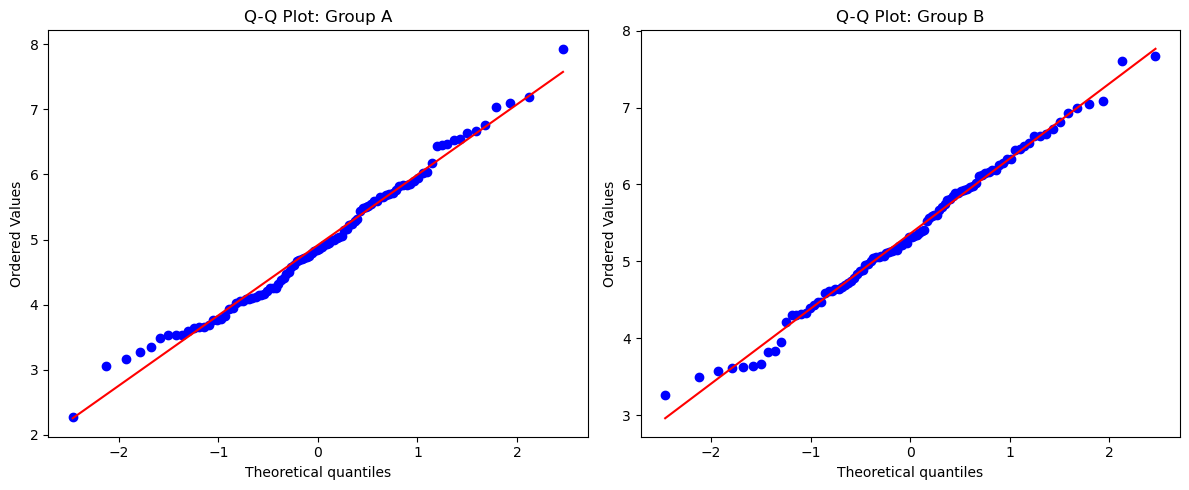

In [10]:
qq_plot_normality(config, df)

<details><summary><strong>📖 Distribution (Click to Expand)</strong></summary>

</details>


📊 Step: Visual Distribution Overview (Side-by-Side)



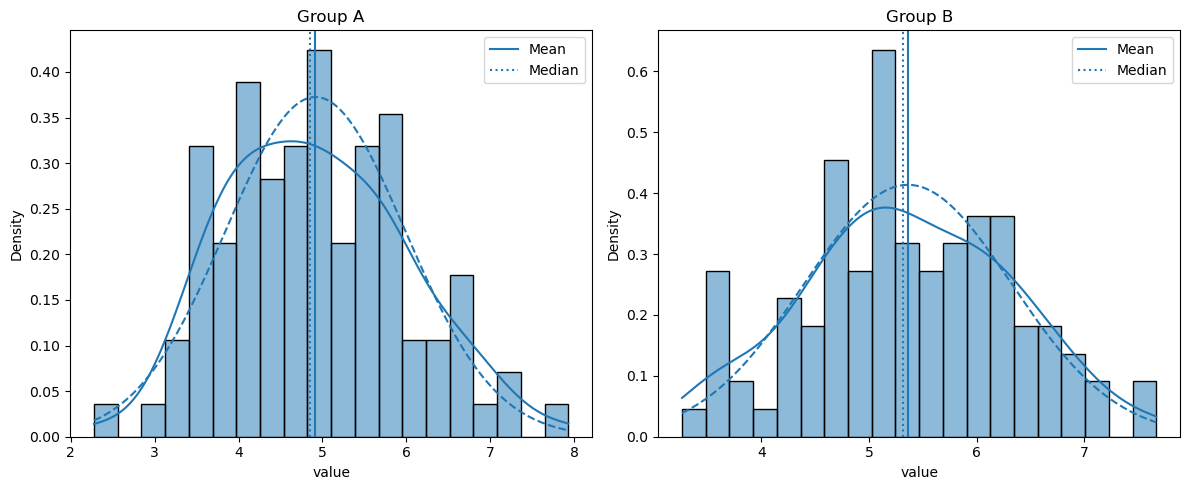

In [11]:
visualize_distribution(config, df)

<hr style="border: none; height: 1px; background-color: #ddd;" />

<a id="check-variance"></a>
#### 📏 Check Variance Equality

<details><summary><strong>📖 Equal Variance Check (Click to Expand)</strong></summary>

##### 📘 Why Are We Checking for Equal Variance?

When comparing **two independent groups** using a **parametric test** (like a two-sample t-test),  
we assume that both groups have **equal variances** — this is called the **homogeneity of variance** assumption.

Failing to meet this assumption can lead to incorrect conclusions if the wrong test is applied.

---

##### 🧪 Test Used: **Levene’s Test**

Levene’s Test checks whether the **spread (variance)** of values is roughly the same in both groups.

- **Null Hypothesis (H₀)**: Variance in Group A = Variance in Group B  
- **Alternative Hypothesis (H₁)**: Variances are different between the groups

---

##### 🧠 Interpretation:

- **p > 0.05** → Fail to reject H₀ → Variances are **likely equal** ✅  
- **p < 0.05** → Reject H₀ → Variances are **likely unequal** ⚠️

---

##### ✅ When Should You Check This?

- ✔️ Check **only** when:
  - You’re comparing **two groups**
  - The groups are **independent**
  - The outcome is **continuous**

- ❌ Don’t check if:
  - The test is **one-sample**
  - The groups are **paired** (since variance of differences is what matters)

</details>

In [12]:
config = infer_variance_equality(config, df)


📏 **Step: Infer Equality of Variance Across Groups**
📘 We're checking if the spread (variance) of the outcome variable is similar across groups A and B.
   This is important for choosing between a **pooled t-test** vs **Welch’s t-test**.
🔬 Test Used: Levene’s Test for Equal Variance
   H₀: Variance in Group A = Variance in Group B
   H₁: Variances are different

📊 Levene’s Test Result:
• Test Statistic = 1.0751
• p-value        = 0.3011
✅ Fail to reject H₀ → Variances appear equal across groups

📦 Final Decision → config['variance_equal'] = `equal`



📊 Visual Check: Spread Comparison Between Groups
   (Spread = how much values vary within each group)

📋 Spread Summary:


,std_dev,variance,median,IQR
group,,,,
A,1.070873,1.146769,4.853497,1.562018
B,0.964252,0.929781,5.317251,1.363176


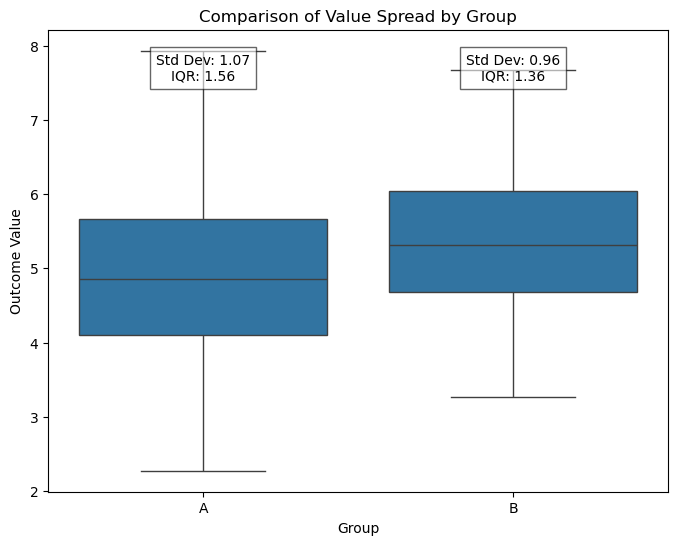


🧠 Business Interpretation:
✅ The spread of values across groups is very similar.
   Variability does not appear meaningfully different.


In [13]:
visualize_variance_boxplot_annotated(config, df)

In [14]:
pretty_json(config)
print_config_summary(config)

📋 Hypothesis Test Configuration Summary

🔸 Outcome Type         : continuous
🔸 Group Relationship   : independent
🔸 Group Count          : two-sample
🔸 Distribution         : normal
🔸 Variance Equal       : equal
🔸 Tail Type            : two-tailed
🔸 Parametric           : None
🔸 Alpha                : 0.05
🔸 Sample Size          : 100
🔸 Effect Size          : 0.5

🧠 Inference Summary:
→ Comparing two independent groups (A vs B).


<hr style="border: none; height: 1px; background-color: #ddd;" />

<a id="check-variance-alt"></a>
#### 📏 Alternative Variance Tests (FYI)

<details><summary><strong>📖 Other Tests for Equal Variance (Click to Expand)</strong></summary>

##### 🧪 1️⃣ Bartlett’s Test

- Assumes data is **normally distributed**
- More powerful than Levene’s under strict normality
- Sensitive to non-normal data

Use when:
- Normality assumption is strongly satisfied.

---

##### 🧪 2️⃣ Fligner–Killeen Test

- Non-parametric
- Does **not** assume normality
- More robust to skewness and outliers

Use when:
- Data is clearly non-normal
- You want a distribution-free alternative.

---

##### 📝 Note

Levene’s test is generally preferred in practice because it is more robust to non-normality.

</details>


<hr style="border: none; height: 1px; background-color: #ddd;" />

<a id="infer-parametric-flag"></a>
#### 📏 Infer Parametric Flag

<details><summary><strong>📖 Parametric vs Non-Parametric (Click to Expand)</strong></summary>

##### 📘 What Does "Parametric" Mean?

A **parametric test** assumes that the data follows a known distribution — typically a **normal distribution**.

These tests also often assume:
- Equal variances between groups (for two-sample cases)
- Independent samples

When those assumptions are met, parametric tests are **more powerful** (i.e., they detect real effects more easily).

---

##### 🔁 What Happens If Assumptions Don’t Hold?

You should use a **non-parametric test** — these don’t rely on strong distributional assumptions and are more robust, especially for small sample sizes or skewed data.

Examples:
| Parametric Test          | Non-Parametric Alternative       |
|--------------------------|----------------------------------|
| Two-sample t-test        | Mann-Whitney U test              |
| Paired t-test            | Wilcoxon Signed-Rank test        |
| ANOVA                    | Kruskal-Wallis test              |

---

##### 🧠 How We Decide Here

In our pipeline, a test is **parametric** only if:

- The outcome variable is **continuous**
- The data is **normally distributed**
- The variance is **equal**, if applicable (or marked `"NA"` for paired designs)

If these aren’t all true, we default to a non-parametric test.

</details>

In [15]:
config = infer_parametric_flag(config)


📏 Step: Decide Between Parametric vs Non-Parametric Approach
🔍 Distribution of outcome = `normal`
✅ Normal distribution → Proceeding with a parametric test

📦 Final Decision → config['parametric'] = `True`


In [16]:
pretty_json(config)
print_config_summary(config)

📋 Hypothesis Test Configuration Summary

🔸 Outcome Type         : continuous
🔸 Group Relationship   : independent
🔸 Group Count          : two-sample
🔸 Distribution         : normal
🔸 Variance Equal       : equal
🔸 Tail Type            : two-tailed
🔸 Parametric           : True
🔸 Alpha                : 0.05
🔸 Sample Size          : 100
🔸 Effect Size          : 0.5

🧠 Inference Summary:
→ Comparing two independent groups (A vs B).


[Back to the top](#table-of-contents)
___


<a id="hypothesis-testing"></a>
<h1>🧪 Hypothesis Testing</h1>

<a id="determine-test"></a>
#### 🧭 Determine Test

<details><summary><strong>📖 How We Select the Right Statistical Test (Click to Expand)</strong></summary>

##### 🧠 What Are We Doing Here?

Based on all the configuration values you’ve either set or inferred (`outcome_type`, `group_relationship`, `distribution`, etc),  
we determine **which statistical test is most appropriate** for your hypothesis.

This is the decision engine of the pipeline.

---

##### ⚙️ How the Logic Works

We go through structured rules based on:

| Config Field           | What it Affects                     |
|------------------------|-------------------------------------|
| `outcome_type`         | Binary / continuous / categorical   |
| `group_count`          | One-sample / two-sample / multi     |
| `group_relationship`   | Independent or paired               |
| `distribution`         | Normal or non-normal                |
| `variance_equal`       | Determines pooled vs Welch’s t-test |
| `parametric`           | Whether to use parametric approach  |

---

##### 🧪 Example Mappings:

| Scenario                                             | Selected Test               |
|------------------------------------------------------|-----------------------------|
| Continuous, 2 groups, normal, equal variance         | Two-sample t-test (pooled)  |
| Continuous, 2 groups, non-normal                     | Mann-Whitney U              |
| Binary, 2 groups, independent                        | Proportions z-test          |
| Continuous, paired, non-normal                      | Wilcoxon Signed-Rank        |
| 3+ groups, categorical outcome                       | Chi-square test             |

</details>


<details><summary><strong>📖 Test Selection Matrix (Click to Expand)</strong></summary>

<table>
  <thead>
    <tr>
      <th>#</th>
      <th>💼 Example Business Problem</th>
      <th>📊 Outcome Variable Type</th>
      <th>📈 Outcome Distribution</th>
      <th>👥 Group Count</th>
      <th>🔗 Groups Type</th>
      <th>✅ Recommended Test</th>
      <th>📝 Notes</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>1</td>
      <td>Is average order value different from $50?</td>
      <td>Continuous</td>
      <td>Normal</td>
      <td>One-Sample</td>
      <td><em>Not Applicable</em></td>
      <td>One-sample t-test</td>
      <td><em>-</em></td>
    </tr>
    <tr>
      <td>2</td>
      <td>Do users who saw recs spend more time on site?</td>
      <td>Continuous</td>
      <td>Normal</td>
      <td>Two-Sample</td>
      <td>Independent</td>
      <td>Two-sample t-test</td>
      <td><em>Use if variances are equal; Welch’s t-test if not</em></td>
    </tr>
    <tr>
      <td>3</td>
      <td>Did users spend more after redesign?</td>
      <td>Continuous</td>
      <td>Normal</td>
      <td>Two-Sample</td>
      <td>Paired</td>
      <td>Paired t-test</td>
      <td><em>Use only if paired differences are roughly Normal</em></td>
    </tr>
    <tr>
      <td>4</td>
      <td>Does time spent differ across A/B/C?</td>
      <td>Continuous</td>
      <td>Normal</td>
      <td>Multi-Sample (3+)</td>
      <td>Independent</td>
      <td>ANOVA</td>
      <td><em>Use Welch ANOVA if group variances differ</em></td>
    </tr>
    <tr>
      <td>5</td>
      <td>Is average order value different from $50 (skewed)?</td>
      <td>Continuous</td>
      <td>Non-Normal</td>
      <td>One-Sample</td>
      <td><em>Not Applicable</em></td>
      <td>Wilcoxon Signed-Rank Test</td>
      <td><em>Use when normality is violated; tests median. Sign Test is an alternative with fewer assumptions</em></td>
    </tr>
    <tr>
      <td>6</td>
      <td>Is revenue different between coupon A vs B?</td>
      <td>Continuous</td>
      <td>Non-Normal</td>
      <td>Two-Sample</td>
      <td>Independent</td>
      <td>Mann-Whitney U test</td>
      <td><em>Use when data is skewed or has outliers</em></td>
    </tr>
    <tr>
      <td>7</td>
      <td>Did time on site change (skewed)?</td>
      <td>Continuous</td>
      <td>Non-Normal</td>
      <td>Two-Sample</td>
      <td>Paired</td>
      <td>Wilcoxon signed-rank test</td>
      <td><em>For paired non-normal distributions</em></td>
    </tr>
    <tr>
      <td>8</td>
      <td>Does spend differ across segments?</td>
      <td>Continuous</td>
      <td>Non-Normal</td>
      <td>Multi-Sample (3+)</td>
      <td>Independent</td>
      <td>Kruskal-Wallis test</td>
      <td><em>Non-parametric version of ANOVA</em></td>
    </tr>
    <tr>
      <td>9</td>
      <td>Is conversion rate different from 10%?</td>
      <td>Binary</td>
      <td><em>Not Applicable</em></td>
      <td>One-Sample</td>
      <td><em>Not Applicable</em></td>
      <td>One-proportion z-test</td>
      <td><em>Use binomial exact test if sample size is small</em></td>
    </tr>
    <tr>
      <td>10</td>
      <td>Does new CTA improve conversion?</td>
      <td>Binary</td>
      <td><em>Not Applicable</em></td>
      <td>Two-Sample</td>
      <td>Independent</td>
      <td>Proportions z-test</td>
      <td><em>Use when counts are raw; chi-square for independence. Fisher’s Exact if expected counts are low</em></td>
    </tr>
    <tr>
      <td>11</td>
      <td>Do users convert more after badges?</td>
      <td>Binary</td>
      <td><em>Not Applicable</em></td>
      <td>Two-Sample</td>
      <td>Paired</td>
      <td>McNemar’s test</td>
      <td><em>Used for 2×2 paired binary outcomes</em></td>
    </tr>
    <tr>
      <td>12</td>
      <td>Do plan choices differ across layout options?</td>
      <td>Categorical</td>
      <td><em>Not Applicable</em></td>
      <td>Multi-Sample (3+)</td>
      <td>Independent</td>
      <td>Chi-square test</td>
      <td><em>Requires expected frequency ≥5 in each cell. Use Fisher’s Exact if assumption fails</em></td>
    </tr>
    <tr>
      <td>13</td>
      <td>Do users add more items to cart?</td>
      <td>Count</td>
      <td>Poisson</td>
      <td>Two-Sample</td>
      <td>Independent</td>
      <td>Poisson / NB test</td>
      <td><em>Use Negative Binomial if variance > mean</em></td>
    </tr>
    <tr>
      <td>14</td>
      <td>Is effect still significant after adjusting for device & region?</td>
      <td>Any</td>
      <td><em>Not Applicable</em></td>
      <td>Any</td>
      <td>Any</td>
      <td>Regression (linear / logistic)</td>
      <td><em>Use to control for covariates / confounders</em></td>
    </tr>
    <tr>
      <td>15</td>
      <td>What’s the probability that B beats A?</td>
      <td>Any</td>
      <td><em>Not Applicable</em></td>
      <td>Two-Sample</td>
      <td>Any</td>
      <td>Bayesian A/B test</td>
      <td><em>Posterior probability; no p-value</em></td>
    </tr>
    <tr>
      <td>16</td>
      <td>Is observed lift statistically rare?</td>
      <td>Any</td>
      <td><em>Not Applicable</em></td>
      <td>Two-Sample</td>
      <td>Any</td>
      <td>Permutation / Bootstrap</td>
      <td><em>Use when parametric assumptions are violated</em></td>
    </tr>
  </tbody>
</table>

</details>


<details>
<summary><strong>📖 Test Selection FlowChart (Click to Expand)</strong></summary>

<pre>
[What is your outcome variable type?]  
  |
  +--> 📏 Continuous
  |     |
  |     +--> Is the outcome distribution normal?
  |           |
  |           +--> ✅ Yes
  |           |     |
  |           |     +--> 👥 Group Count = One-Sample ----------> 🧪 One-sample t-test
  |           |     +--> 👥 Group Count = Two-Sample
  |           |     |           +-->  🔗 Groups Type = Independent
  |           |     |           |            |
  |           |     |           |            +--> Are variances equal?
  |           |     |           |            |
  |           |     |           |            +--> ✅ Yes ------> 🧪 Two-sample t-test (pooled)
  |           |     |           |            +--> ❌ No  ------> 🧪 Welch’s t-test
  |           |     |           +--> 🔗 Groups Type = Paired --> 🧪 Paired t-test
  |           |     +--> 👥 Group Count = Multi-Sample (3+)
  |           |                              |
  |           |                              +--> Are variances equal?
  |           |                              |
  |           |                              +--> ✅ Yes ------> 🧪 ANOVA
  |           |                              +--> ❌ No  ------> 🧪 Welch ANOVA
  |           |
  |           +--> ❌ No (Non-Normal)
  |                 |
  |                 +--> 👥 Group Count = One-Sample ----------> 🧪 Wilcoxon Signed-Rank Test
  |                 +--> 👥 Group Count = Two-Sample
  |                 |     +--> 🔗 Groups Type = Independent ---> 🧪 Mann-Whitney U Test
  |                 |     +--> 🔗 Groups Type = Paired --------> 🧪 Wilcoxon Signed-Rank Test
  |                 +--> 👥 Group Count = Multi-Sample (3+) ---> 🧪 Kruskal-Wallis Test
  |
  +--> ⚪ Binary
  |     |
  |     +--> 👥 Group Count = One-Sample -----------------------> 🧪 One-proportion z-test
  |     +--> 👥 Group Count = Two-Sample
  |     |     +--> 🔗 Groups Type = Independent ---------------> 🧪 Proportions z-test
  |     |     +--> 🔗 Groups Type = Paired --------------------> 🧪 McNemar’s Test
  |
  +--> 🟪 Categorical
  |     |
  |     +--> 👥 Group Count = Multi-Sample (3+) ---------------> 🧪 Chi-square Test
  |
  +--> 🔢 Count
  |     |
  |     +--> Distribution = Poisson
  |           +--> 👥 Group Count = Two-Sample ---------------> 🧪 Poisson or Negative Binomial Test
  |
  +--> 🧠 Any
        |
        +--> Want to control for covariates? -------------> 📉 Regression (Linear or Logistic)
        +--> Prefer probability over p-values? -----------> 📊 Bayesian A/B Test
        +--> Assumptions violated / custom metric? -------> 🔁 Permutation or Bootstrap
</pre>

</details>

In [17]:
config['test_name'] = determine_test_to_run(config)


🧭 Step: Determine Which Statistical Test to Use
📦 Inputs:
• Outcome Type         = `continuous`
• Group Count          = `two-sample`
• Group Relationship   = `independent`
• Distribution         = `normal`
• Equal Variance       = `equal`
• Parametric Flag      = `True`

🔍 Matching against known test cases...

✅ Selected Test: `two_sample_ttest_pooled`


<hr style="border: none; height: 1px; background-color: #ddd;" />

<a id="print-hypothesis"></a>
#### 🧠 Print Hypothesis

<details><summary><strong>📖 Hypothesis Structure & Interpretation (Click to Expand)</strong></summary>

##### 📘 What Are We Doing Here?

This step generates a **formal hypothesis statement** for the selected test.

Every statistical test is built around two competing ideas:

- **H₀ (Null Hypothesis)** → The “status quo”. There is **no effect**, **no difference**, or **no association**.
- **H₁ (Alternative Hypothesis)** → There **is** an effect, difference, or relationship.

---

##### 🧪 Examples of Hypothesis Pairs

| Test Type                     | Null Hypothesis (H₀)                                                     | Alternative (H₁)                                                    |
|-------------------------------|---------------------------------------------------------------------------|----------------------------------------------------------------------|
| One-sample t-test            | The average value equals the reference value                            | The average value is different (or higher / lower)                  |
| Two-sample t-test            | The average outcome is the same in both groups                          | The average outcome differs between the groups                      |
| Welch’s t-test               | The average outcome is the same in both groups                          | The average outcome differs between the groups                      |
| Paired t-test                | The average change between before and after is zero                     | The average change is not zero                                      |
| ANOVA                        | The average outcome is the same across all groups                       | At least one group has a different average outcome                  |
| Welch ANOVA                  | The average outcome is the same across all groups                       | At least one group has a different average outcome                  |
| Wilcoxon Signed-Rank Test    | The typical value equals the reference (or no typical change observed)  | The typical value differs (or typical change exists)                |
| Mann-Whitney U Test          | The outcome pattern is the same in both groups                          | One group generally has higher values than the other                |
| Kruskal-Wallis Test          | The outcome pattern is the same across all groups                       | At least one group differs in outcome pattern                       |
| One-proportion z-test        | The conversion rate equals the reference rate                           | The conversion rate differs from the reference rate                 |
| Proportions z-test           | The conversion rate is the same in both groups                          | The conversion rate differs between groups                          |
| McNemar’s test               | The proportion of “Yes” responses is the same before and after          | The proportion changes after the intervention                       |
| Chi-square test              | Category preferences are the same across groups                         | Category preferences differ across groups                           |
| Poisson test                 | The average event rate is the same in both groups                       | The event rate differs between groups                               |
| Negative Binomial test       | The average event rate is the same in both groups                       | The event rate differs between groups                               |
| Regression (linear/logistic) | The variable being tested has no meaningful impact on the outcome       | The variable being tested impacts the outcome                       |
| Bayesian A/B test            | Version B is not more likely to outperform Version A                    | Version B is more likely to outperform Version A                    |
| Permutation / Bootstrap      | The observed difference is consistent with random chance                | The observed difference is unlikely due to random chance            |

---




</details>

In [18]:
config['H_0'], config['H_a'] = print_hypothesis_statement(config)


🧠 Step: Generate Hypothesis Statement
🔍 Selected Test        : `two_sample_ttest_pooled`
🔍 Tail Type            : `two-tailed`

📜 Hypothesis Statement:
• H₀: The outcome (mean/proportion) is the same across groups A and B.
• H₁: The outcome differs between groups.


<hr style="border: none; height: 1px; background-color: #ddd;" />

<a id="run-test"></a>
#### 🧪 Run Hypothesis Test

<details><summary><strong>📖 Running the Hypothesis Test (Click to Expand)</strong></summary>

##### 🧠 What Happens in This Step?

This function takes in your final config + dataset and **executes the appropriate test** — outputting:
- The test statistic (e.g., t, z, chi², U, F)
- The p-value
- Whether the result is statistically significant

##### 🧪 Interpreting the Output

| Field         | What It Means |
|---------------|----------------|
| `statistic`   | The test result (e.g., t-score, chi-square, etc) |
| `p_value`     | Probability of seeing this result by chance |
| `significant` | `True` if `p < alpha` (reject H₀), else `False` |
| `alpha`       | The pre-defined significance threshold (typically 0.05) |

##### 📏 Significance Logic

- If **p < alpha** → reject the null hypothesis  
- If **p ≥ alpha** → fail to reject the null

##### ⚠️ Robustness

The function handles different test types:
- Parametric (e.g., t-tests, ANOVA)
- Non-parametric (e.g., Wilcoxon, Mann-Whitney)
- Binary proportions (e.g., z-test, McNemar)
- Multi-group (e.g., ANOVA, chi-square)
- Even fallback with `test_not_found`

</details>

📜 Hypothesis Being Tested:
• H₀: The outcome (mean/proportion) is the same across groups A and B.
• H₁: The outcome differs between groups.


🧪 Step: Run Hypothesis Test
✅ Selected Test        : `two_sample_ttest_pooled`
🔍 Significance Threshold (α) : 0.05

🚀 Executing statistical test...

📊 Test Summary: Two Sample Ttest Pooled

🧪 Technical Result
• Test Statistic (t-statistic) = -3.0942
• P-value            = 0.0023
• Alpha (α)          = 0.05


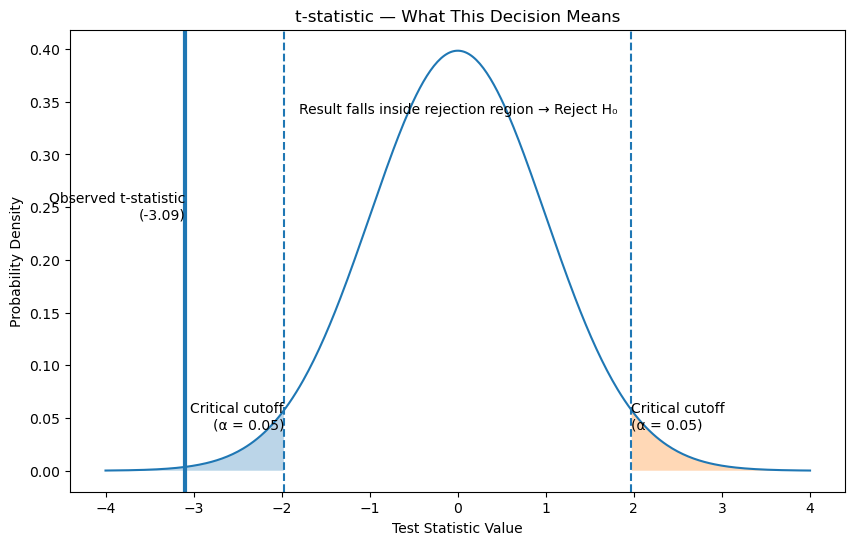

• Conclusion         = ✅ Statistically significant → Reject H₀

📈 Interpretation
• The observed difference is unlikely due to random variation.

💼 Business Insight
• Group A mean = 4.92
• Group B mean = 5.36
• Lift = 0.45 (+9.07%)
🏆 Group B outperforms Group A — and the effect is statistically significant.


In [19]:
_ = run_hypothesis_test(config, df)

[Back to the top](#table-of-contents)    
___
